In [1]:
from dace_query.sun import Sun

from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from datetime import datetime, timedelta

from scipy.optimize import curve_fit
import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar
import logging  # to avoid printing too many warnings

import tools as t

2026-06-20 19:54:31,323 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


[dace-query] Update available: 3.0.0 → 3.0.2


## Spectra

In [2]:
# define the path of the directory where dace data is saved
path_dace = '../data/dace_sun/'
direc = 'Jan2017/'  # sub directory where the specific data is
# load absorption bands
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [3]:
# iterate over saved files in direc
# save names (observation dates) of the files
dates_files = []
for entry in os.scandir(path_dace + direc):
    if entry.name != 'spectra.txt' and entry.name != 'CCF':
        dates_files.append(entry.name)

dates_files = sorted(dates_files, key=lambda d: datetime.strptime(d, "%Y-%m-%d"))  # sort
print(dates_files)

['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-06', '2017-01-09', '2017-01-10', '2017-01-15', '2017-01-16', '2017-01-18', '2017-01-19', '2017-01-20', '2017-01-21', '2017-01-23', '2017-01-24', '2017-01-25', '2017-01-26']


In [4]:
# make a list of the available files that end by A.fits (s1d)
files_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_list.extend(files)  # save file names
files_list = [s for s in files_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_list = np.array(files_list)
print(f's1d files: {len(files_list)}')

# make a list of the available files that end by A.fits (CCF)
files_ccf_list = []
for d in dates_files:  # iterate over directories
    date_path = path_dace + direc + 'CCF/' + d + '/'
    files = os.scandir(date_path)  # files in directory
    files = list(files)
    files = [d + '/' + i.name for i in files]  # list of file names
    files_ccf_list.extend(files)  # save file names
#files_ccf_list = [s for s in files_ccf_list if s.endswith('A.fits')]  # keep only the files that end by A.fits
files_ccf_list = np.array(files_ccf_list)
print(f'ccf files: {len(files_ccf_list)}')

s1d files: 294
ccf files: 333


In [5]:
# keep only ccf files that have a corresponding s1d file
files_s1d = []
files_ccf = []

for i in files_ccf_list:
    s1d_file = i.replace('CCF', 'S1D')
    if s1d_file in files_list:
        files_s1d.append(s1d_file)
        files_ccf.append(i)

files_s1d = np.array(files_s1d)
files_ccf = np.array(files_ccf)
print(len(files_ccf), len(files_s1d))

250 250


In [6]:
# recover dates only
dates = []
for f in files_ccf:
    path_file = path_dace + direc + 'CCF/' + f
    hdul = fits.open(path_file)
    hdr0 = hdul[0].header
    dates.append(datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f'))

dates = np.array(dates)

In [7]:
step_days = 4  # divide de month in steps of this size
total_days = 31
day_ranges = t.build_day_ranges(step_days, total_days)
day_ranges = day_ranges[:-1]  # take out last element so all have the same size (avoids plotting problems at the end)

files_grouped_s1d = {}
files_grouped_ccf = {}

for i in range(len(dates)):
    day = dates[i].day
    for j in day_ranges:
        if j[0] <= day <= j[1]:
            group = day_ranges.index(j)
            if group not in files_grouped_s1d.keys():
                files_grouped_s1d[group] = [files_s1d[i]]
                files_grouped_ccf[group] = [files_ccf[i]]
            else:
                files_grouped_s1d[group].append(files_s1d[i])
                files_grouped_ccf[group].append(files_ccf[i])

day_ranges = np.array(day_ranges)

In [8]:
# extract data from s1d files
spectra = {}
err = {}

for group in files_grouped_s1d.keys():
    for f in files_grouped_s1d[group]:
        path_file = path_dace + direc + f
        hdul = fits.open(path_file)  # open file
        if group not in spectra.keys():
            spectra[group] = [hdul[1].data['flux']]  # save spectrum
            err[group] = [hdul[1].data['error']]  # save flux error
        else:
            spectra[group].append(hdul[1].data['flux'])  # save spectrum
            err[group].append(hdul[1].data['error'])  # save flux error

# extract data from ccf files
rv = {}
dates = {}
julian_dates = {}

for group in files_grouped_ccf.keys():
    for f in files_grouped_ccf[group]:
        path_file = path_dace + direc + 'CCF/' + f
        hdul = fits.open(path_file)  # open file
        hdr0 = hdul[0].header
        if group not in rv.keys():
            rv[group] = [hdr0['TNG QC CCF RV']]  # save rv
            dates[group] = [datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f')]  # save date
            julian_dates[group] = [hdr0['MJD-OBS']]  # save julian date
        else:
            rv[group].append(hdr0['TNG QC CCF RV'])  # save rv
            dates[group].append(datetime.strptime(hdr0['DATE-OBS'], '%Y-%m-%dT%H:%M:%S.%f'))  # save date
            julian_dates[group].append(hdr0['MJD-OBS'])  # save julian date

In [9]:
# extract wavelength (same for all files)
filename = path_dace + direc + files_list[0]
s1d = fits.getdata(filename, 1)  # load file
wl = s1d['wavelength_air']  # angstrom

In [10]:
# take out projection over the velocity vector

mean_spec = {}
S_f = {}
D = {}
spectra_centered = {}

for i in spectra.keys():
    s = np.array(spectra[i])
    mean_spec[i] = np.mean(s, axis=0)  # save mean spectrum
    sub_v = t.subtract_v(wl, s)
    S_f[i] = sub_v[0]
    D[i] = sub_v[1]
    spectra_centered[i] = t.double_centering(sub_v[0])

In [11]:
# apply PCA to the centered spectra matrix
n_components = 10
loadings = {}
scores = {}
for i in spectra_centered.keys():
    pca_flux = PCA(n_components=n_components)
    pcs  = pca_flux.fit_transform(spectra_centered[i])
    loadings[i] = pca_flux.components_
    scores[i] = np.array([pcs[:, j] for j in range(n_components)])

In [ ]:
# check if PCs are orthogonal to the mean spectrum
np.dot(loadings[0][0], np.gradient(np.mean(spectra_centered[0], axis=0), wl))  # must be zero!

np.float64(1.4739926788102941e-13)

In [48]:
# periodograms and correlation coefficient

periodograms = {}
corr = {}
for i in scores.keys():
    periodograms[i] = [LombScargle(julian_dates[i], scores[i][j]).autopower() for j in range(n_components)]  # returns frequency in days^-1
    corr[i] = np.array([ss.pearsonr(scores[i][j], rv[i])[0] for j in range(n_components)])

/tmp/ipykernel_2818187/2032731880.py:7: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr[i] = np.array([ss.pearsonr(scores[i][j], rv[i])[0] for j in range(n_components)])


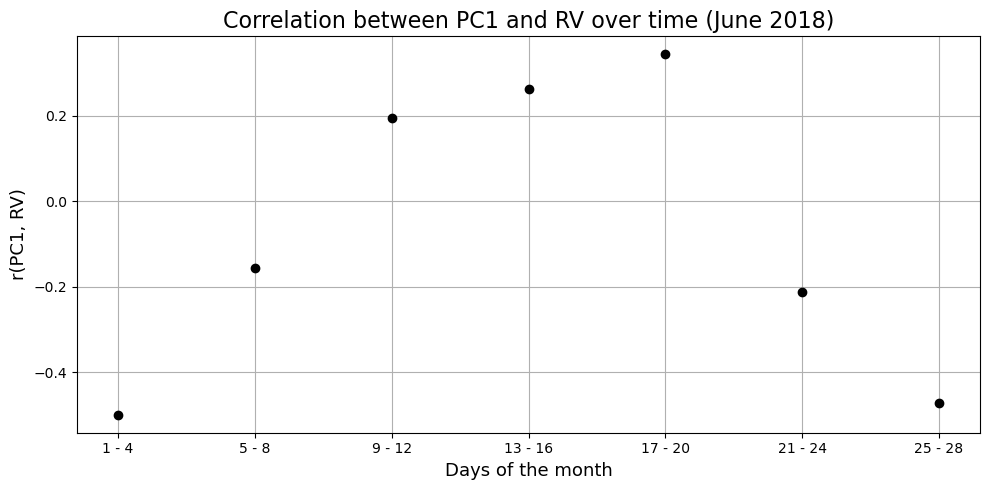

In [ ]:
# plot PC1-RV correlation over time
corr_pc1 = [i[0] for i in corr.values()]

# x positions = midpoint of each time range
x = np.array([np.mean(i) for i in day_ranges])
# x tick labels
xlabels = [f'{start} - {end}' for start, end in day_ranges]

# plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()
ax.scatter(x[list(spectra.keys())], corr_pc1, color='k', zorder=2)

# set ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=0)

ax.set_xlabel('Days of the month', size=13)
ax.set_ylabel('r(PC1, RV)', size=13)
ax.set_title('Correlation between PC1 and RV over time (June 2018)', size=16)

plt.tight_layout()
plt.show()


In [50]:
# print PC1 and PCs with the highest r for each step
corr_threshold = .5
best_pcs = {}
day_index = 0
for i in corr.keys():
    comps_max = np.where(np.abs(corr[i]) > corr_threshold)[0]
    start, end = day_ranges[list(spectra.keys())][day_index]
    print(f'From day {start} to day {end}:')
    print(f'PC1: r = {corr[i][0]:.3f}')
    for j in comps_max:
        if j == 0:
            pass
        else:
            print(f'PC{j + 1}: r = {corr[i][j]:.3f}')
    print('-' * 25)
    # save the information
    if 0 not in comps_max:
        comps_max = np.insert(comps_max, 0, 0)
    best_pcs[i] = comps_max
    day_index += 1

From day 1 to day 4:
PC1: r = -0.499
-------------------------
From day 5 to day 8:
PC1: r = -0.155
PC8: r = 0.623
-------------------------
From day 9 to day 12:
PC1: r = 0.194
-------------------------
From day 13 to day 16:
PC1: r = 0.264
-------------------------
From day 17 to day 20:
PC1: r = 0.343
-------------------------
From day 21 to day 24:
PC1: r = -0.212
-------------------------
From day 25 to day 28:
PC1: r = -0.472
-------------------------


Respective correlation coefficients: [-0.49922424]


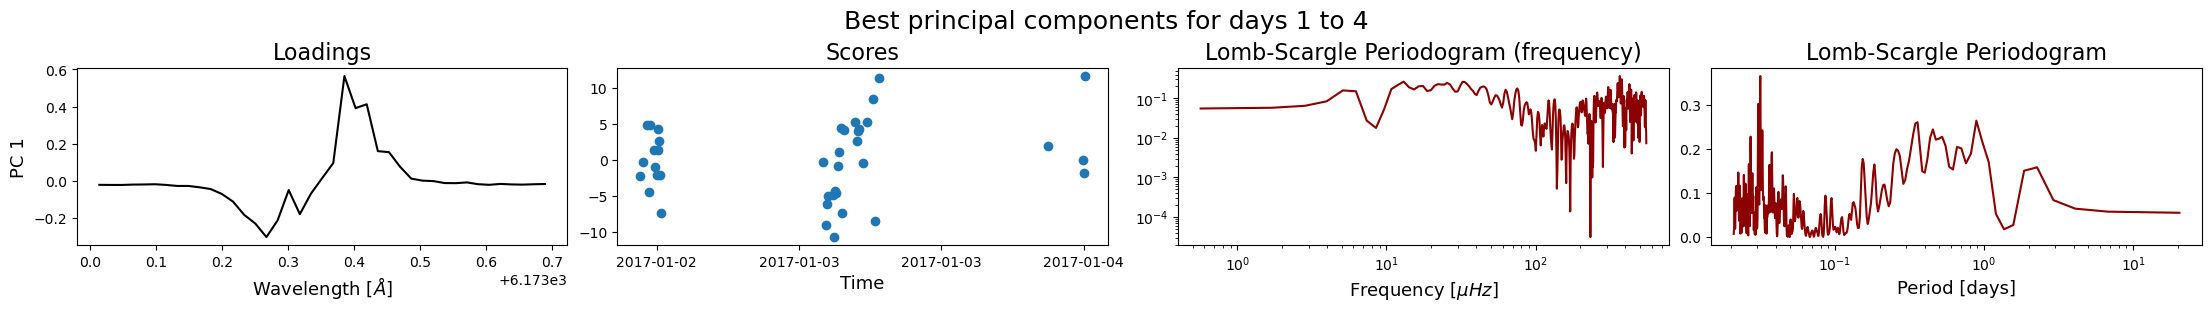

Respective correlation coefficients: [-0.15528861  0.62263026]


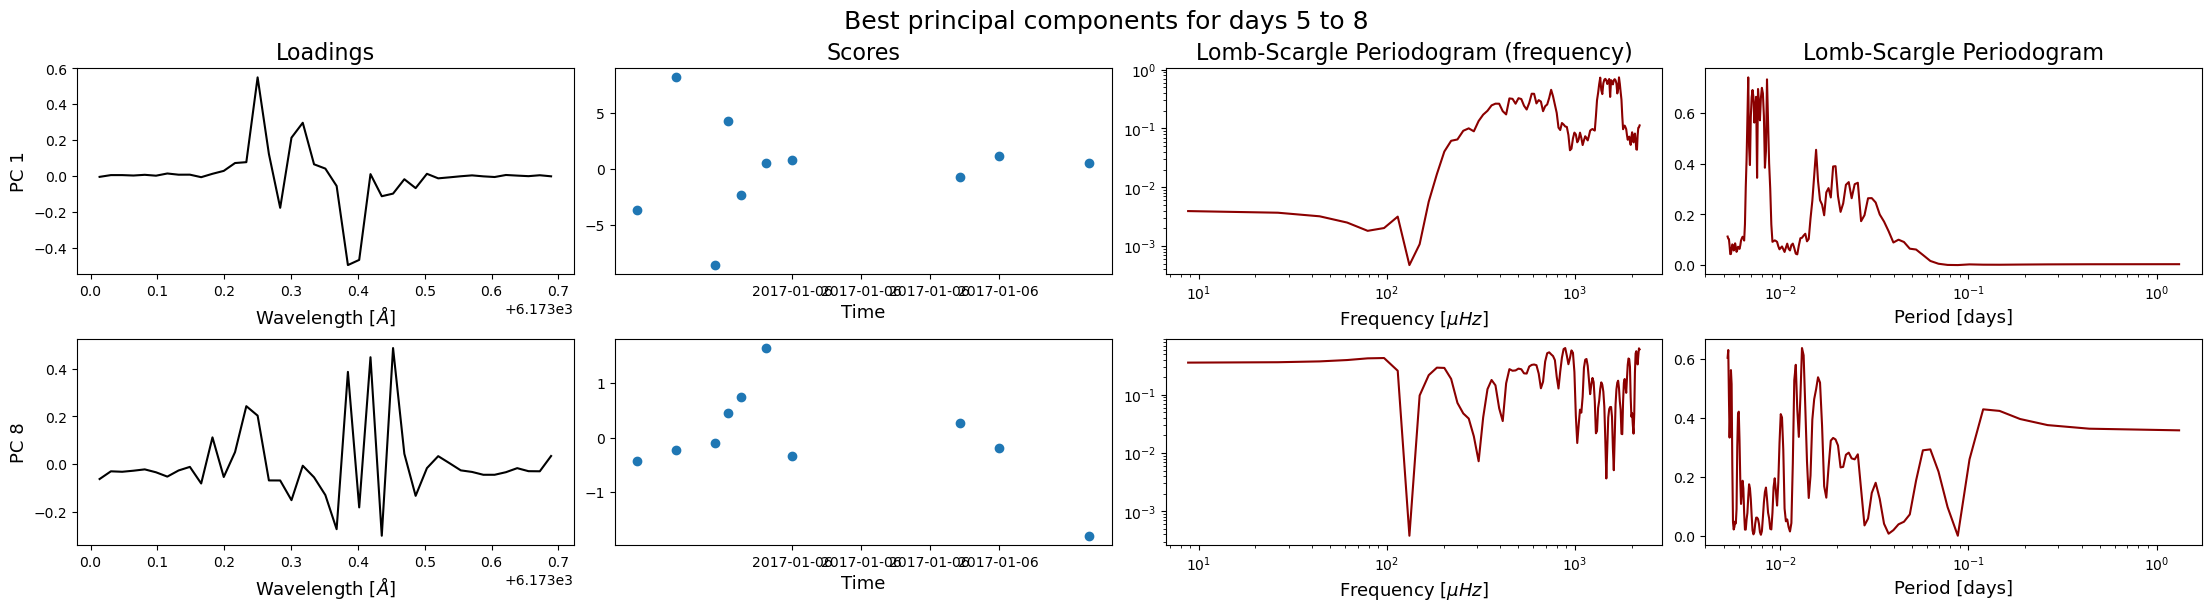

Respective correlation coefficients: [0.19419208]


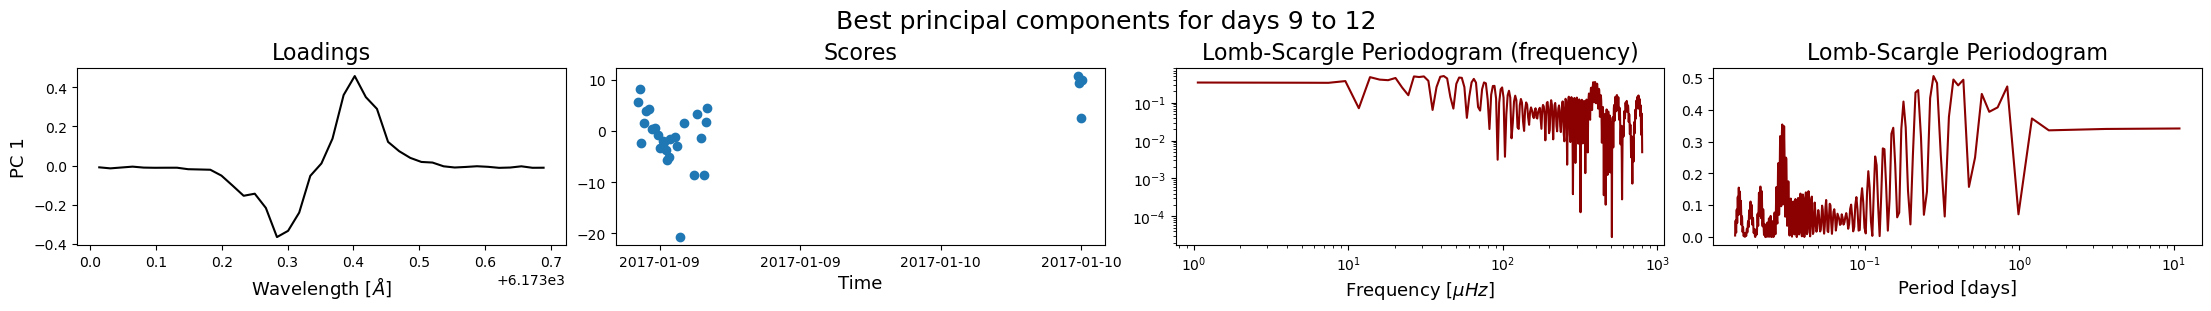

Respective correlation coefficients: [0.26353736]


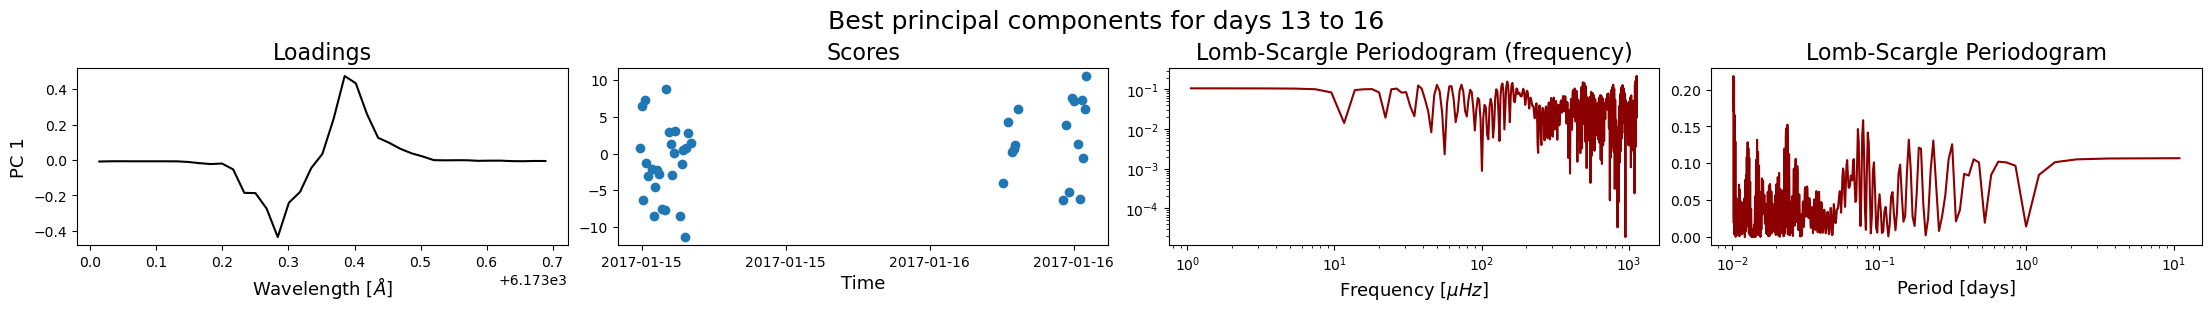

Respective correlation coefficients: [0.34347712]


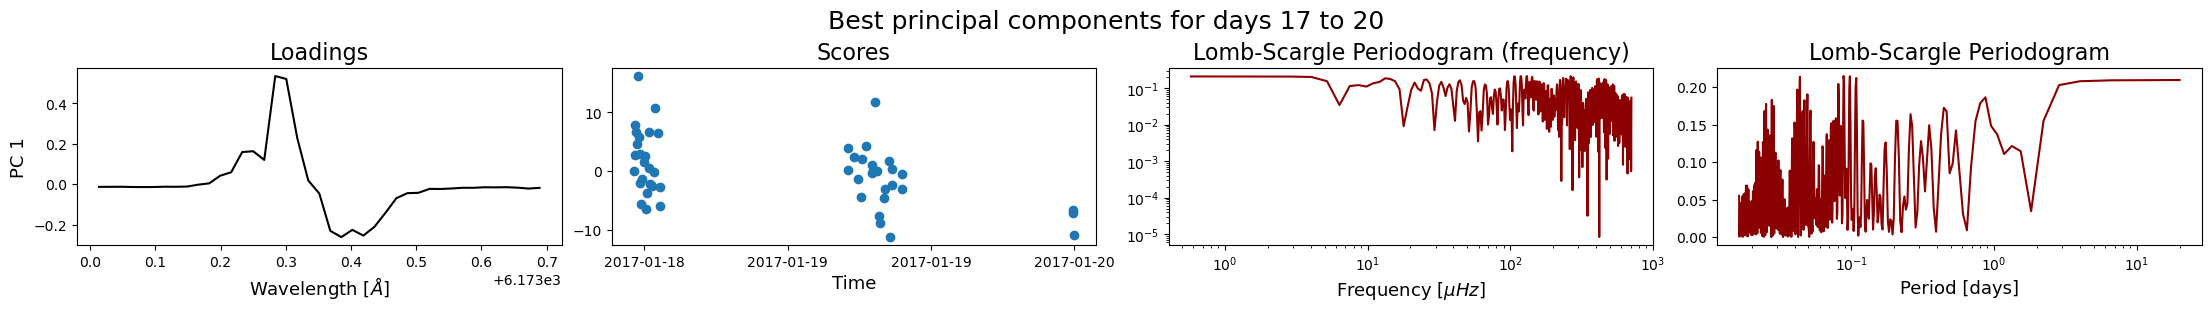

Respective correlation coefficients: [-0.21237682]


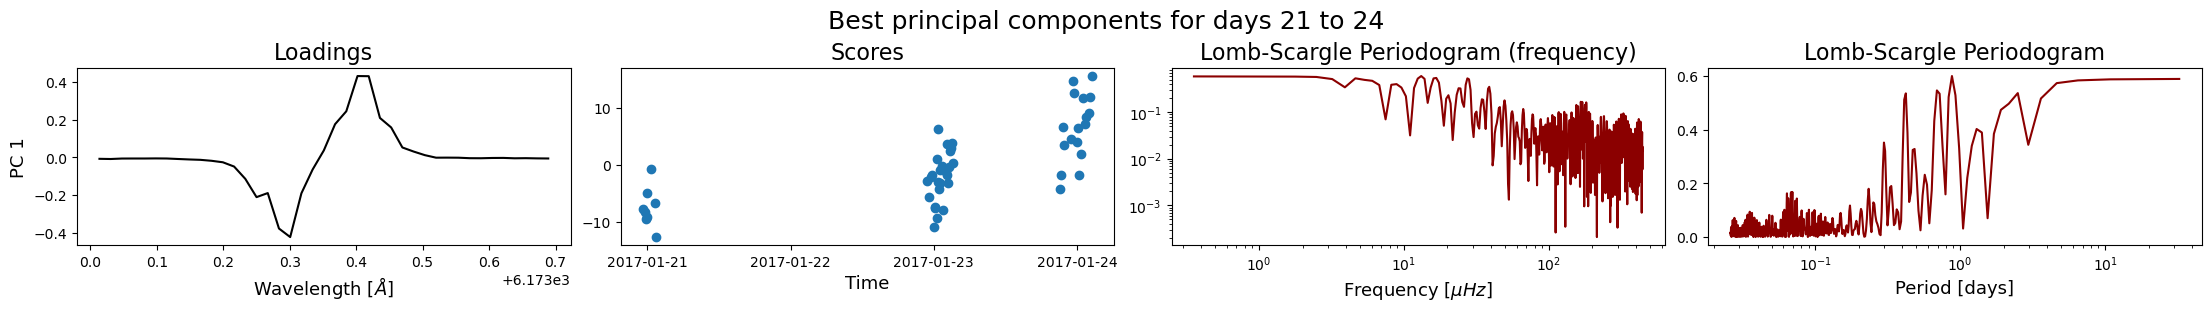

Respective correlation coefficients: [-0.47199634]


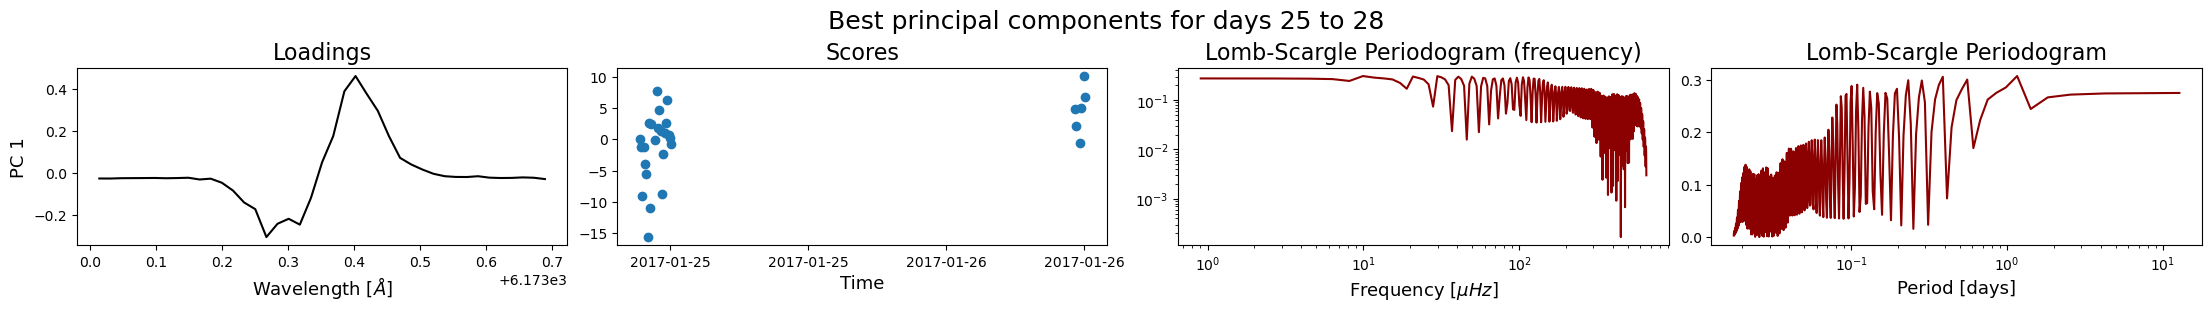

In [54]:
day_index = 0
for i in best_pcs.keys():
    print(f'Respective correlation coefficients: {corr[i][best_pcs[i]]}')
    t.plot_PCA(wl, loadings[i], dates[i], scores[i], periodograms[i], best_pcs[i], day_ranges[list(spectra.keys())][day_index])
    day_index += 1